# Future of Data: Quantum Analytics — Data Analytics Project

**Project Scope:** Analyze the trajectory of quantum computing hardware
progress across leading companies and technology approaches (Superconducting,
Trapped Ion, Photonic, Neutral Atom, Quantum Annealing, Silicon Spin) to
understand how qubit counts, error rates, funding, and commercial
availability are evolving — and build models that predict commercial
readiness and future qubit-count trajectories.

> **Note on the data:** This project uses a **synthetically generated**
> dataset designed to illustrate realistic industry trends and relationships
> (e.g. exponential qubit-count growth, error-rate improvement over time,
> funding scaling with maturity). Figures are simulated for
> learning/demonstration purposes and are **not** real reported company data.

**Workflow covered in this notebook:**
1. Data Loading & Inspection
2. Data Cleaning
3. Exploratory Data Analysis (EDA) & Visualization
4. Key Industry Insights
5. Prediction Models (Commercial Availability Classification + Qubit Count Regression)
6. Conclusion


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report,
                              mean_absolute_error, mean_squared_error, r2_score)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


## 2. Load the Raw Dataset

The raw dataset simulates quarterly/monthly quantum hardware progress reports across 12 companies and intentionally contains data quality issues (missing values, duplicates, inconsistent text formatting, and a few invalid values) so the cleaning process below is meaningful.

In [2]:
raw_df = pd.read_csv("../dataset/raw_quantum_analytics_data.csv")
print("Shape:", raw_df.shape)
raw_df.head()


Shape: (994, 14)


,record_id,announcement_date,company,country,technology_type,qubit_count,gate_error_rate_pct,coherence_time_us,quantum_volume,funding_raised_million_usd,publications_count,patents_filed,sector_focus,is_commercially_available
0,460,2022-10-31,D-Wave,Canada,Quantum Annealing,19701,2.629,72.5,491.0,643.9,5,5,Finance,1
1,284,2025-05-31,IonQ,USA,Trapped Ion,176,0.355,93.6,54.0,591.0,8,2,AI/ML,1
2,173,2023-08-31,Google,USA,Superconducting,968,0.727,67.7,376.0,1643.9,7,2,Cryptography,1
3,47,2021-03-31,IBM,USA,Superconducting,247,1.121,67.2,104.0,1021.8,8,2,General Research,1
4,220,2019-10-31,IonQ,USA,Trapped Ion,12,1.620,20.0,5.0,271.4,1,0,Finance,0


In [3]:
raw_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   994 non-null    int64  
 1   announcement_date           994 non-null    str    
 2   company                     994 non-null    str    
 3   country                     994 non-null    str    
 4   technology_type             994 non-null    str    
 5   qubit_count                 994 non-null    int64  
 6   gate_error_rate_pct         965 non-null    float64
 7   coherence_time_us           970 non-null    float64
 8   quantum_volume              975 non-null    float64
 9   funding_raised_million_usd  975 non-null    float64
 10  publications_count          994 non-null    int64  
 11  patents_filed               994 non-null    int64  
 12  sector_focus                980 non-null    str    
 13  is_commercially_available   994 non-null    in

In [4]:
print("Missing values per column:")
print(raw_df.isna().sum())
print("\nDuplicate rows:", raw_df.duplicated().sum())
print("\nCommercial availability rate:", round(raw_df['is_commercially_available'].mean(), 3))


Missing values per column:
record_id                      0
announcement_date              0
company                        0
country                        0
technology_type                0
qubit_count                    0
gate_error_rate_pct           29
coherence_time_us             24
quantum_volume                19
funding_raised_million_usd    19
publications_count             0
patents_filed                  0
sector_focus                  14
is_commercially_available      0
dtype: int64

Duplicate rows: 11

Commercial availability rate: 0.404


## 3. Data Cleaning

Steps: standardize text formatting (including restoring correct brand-name capitalization like 'IBM' and 'IonQ' which title-casing would otherwise mangle), parse dates, remove duplicates, fix invalid values (negative qubit counts, impossible error rates), and impute missing values using per-technology medians.

In [5]:
df = raw_df.copy()

# Standardize categorical text columns
text_cols = ["company", "country", "technology_type", "sector_focus"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()
    df[col] = df[col].replace("Nan", np.nan)

# Restore correct brand-name capitalization (title-case breaks acronym-style names)
company_name_fix = {"Ibm": "IBM", "Ionq": "IonQ", "Psiquantum": "PsiQuantum", "Quera": "QuEra"}
df["company"] = df["company"].replace(company_name_fix)

# Parse dates
df["announcement_date"] = pd.to_datetime(df["announcement_date"], errors="coerce")
df = df.dropna(subset=["announcement_date"])

# Remove duplicates
df = df.drop_duplicates()
df = df.drop_duplicates(subset=["record_id"])

# Fix invalid values
df.loc[df["qubit_count"] < 0, "qubit_count"] = df.loc[df["qubit_count"] < 0, "qubit_count"].abs()
df.loc[df["gate_error_rate_pct"] > 100, "gate_error_rate_pct"] = np.nan

# Impute missing values with per-technology median
for col in ["gate_error_rate_pct", "coherence_time_us", "quantum_volume", "funding_raised_million_usd"]:
    df[col] = df.groupby("technology_type")[col].transform(lambda s: s.fillna(s.median()))
    df[col] = df[col].fillna(df[col].median())
df["sector_focus"] = df["sector_focus"].fillna(df["sector_focus"].mode()[0])

# Derived columns
df["year"] = df["announcement_date"].dt.year
df["quarter"] = df["announcement_date"].dt.to_period("Q").astype(str)
df["qubits_per_error"] = (df["qubit_count"] / df["gate_error_rate_pct"].replace(0, np.nan)).round(1).fillna(0)

print("Cleaned shape:", df.shape)
print("Remaining missing values:", df.isna().sum().sum())
df.head()


Cleaned shape: (983, 17)
Remaining missing values: 0


,record_id,announcement_date,company,country,technology_type,qubit_count,gate_error_rate_pct,coherence_time_us,quantum_volume,funding_raised_million_usd,publications_count,patents_filed,sector_focus,is_commercially_available,year,quarter,qubits_per_error
0,460,2022-10-31,D-Wave,Canada,Quantum Annealing,19701,2.629,72.5,491.0,643.9,5,5,Finance,1,2022,2022Q4,7493.7
1,284,2025-05-31,IonQ,Usa,Trapped Ion,176,0.355,93.6,54.0,591.0,8,2,Ai/Ml,1,2025,2025Q2,495.8
2,173,2023-08-31,Google,Usa,Superconducting,968,0.727,67.7,376.0,1643.9,7,2,Cryptography,1,2023,2023Q3,1331.5
3,47,2021-03-31,IBM,Usa,Superconducting,247,1.121,67.2,104.0,1021.8,8,2,General Research,1,2021,2021Q1,220.3
4,220,2019-10-31,IonQ,Usa,Trapped Ion,12,1.620,20.0,5.0,271.4,1,0,Finance,0,2019,2019Q4,7.4


In [6]:
# Save the cleaned dataset (already produced by src/01_data_cleaning.py, re-saved here for notebook completeness)
df.to_csv("../dataset/cleaned_quantum_analytics_data.csv", index=False)
df.describe(include="all").T.head(15)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
record_id,983.0,NaN,NaN,NaN,492.0,1.0,246.5,492.0,737.5,983.0,283.911958
announcement_date,983,NaN,NaN,NaN,2022-11-18 07:01:53.530010,2017-01-31 00:00:00,2021-03-31 00:00:00,2022-12-31 00:00:00,2024-09-30 00:00:00,2026-06-30 00:00:00,NaN
company,983,12,D-Wave,116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,983,5,Usa,585,NaN,NaN,NaN,NaN,NaN,NaN,NaN
technology_type,983,6,Superconducting,382,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qubit_count,983.0,NaN,NaN,NaN,3658.784334,3.0,34.0,122.0,631.5,114586.0,13265.450198
gate_error_rate_pct,983.0,NaN,NaN,NaN,1.996379,0.271,0.933,1.658,2.5935,45.93,2.421589
coherence_time_us,983.0,NaN,NaN,NaN,47.124873,5.0,24.95,40.4,65.0,156.7,29.597812
quantum_volume,983.0,NaN,NaN,NaN,180.247202,2.0,6.5,18.0,72.0,3378.0,445.029977
funding_raised_million_usd,983.0,NaN,NaN,NaN,670.525229,148.0,336.2,543.0,890.5,2399.7,443.514762


## 4. Exploratory Data Analysis & Visualization

### 4.1 Qubit Count Growth by Technology Type (Log Scale)

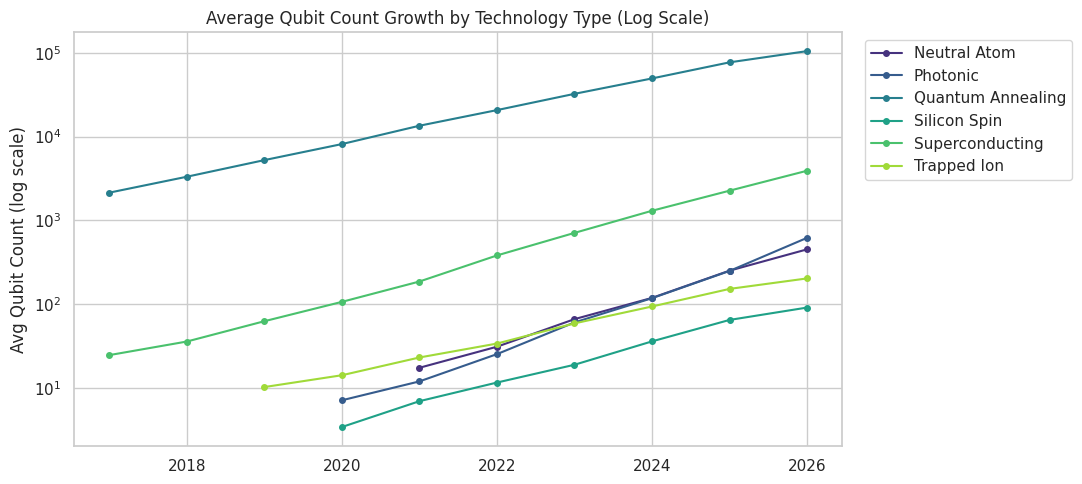

In [7]:
yearly_tech = df.groupby(["year","technology_type"])["qubit_count"].mean().reset_index()
pivot = yearly_tech.pivot(index="year", columns="technology_type", values="qubit_count")

plt.figure(figsize=(11,5))
for tech in pivot.columns:
    plt.plot(pivot.index, pivot[tech], marker="o", markersize=4, label=tech)
plt.yscale("log")
plt.title("Average Qubit Count Growth by Technology Type (Log Scale)")
plt.ylabel("Avg Qubit Count (log scale)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()


### 4.2 Most Recent Qubit Count by Company

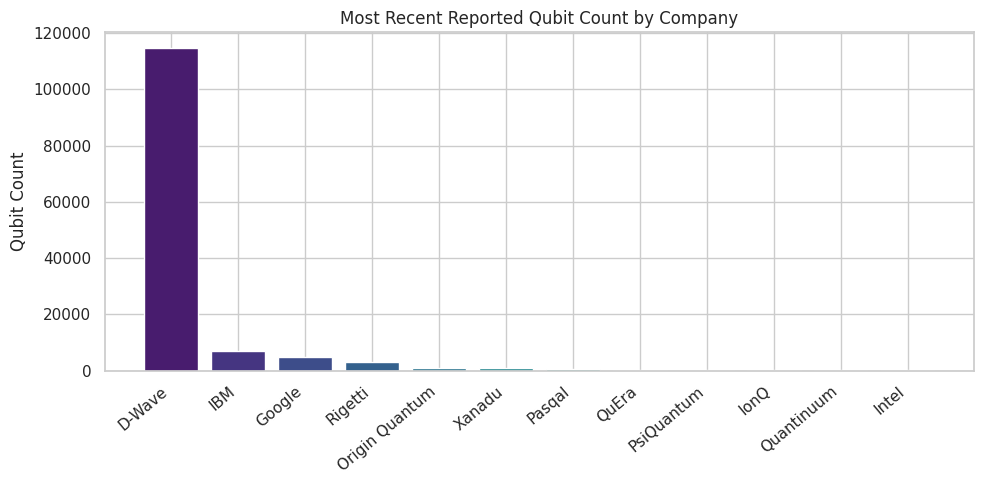

In [8]:
latest = df.sort_values("announcement_date").groupby("company").tail(1).sort_values("qubit_count", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(latest["company"], latest["qubit_count"], color=sns.color_palette("viridis", len(latest)))
plt.title("Most Recent Reported Qubit Count by Company")
plt.ylabel("Qubit Count")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()


### 4.3 Commercial Availability Rate by Technology

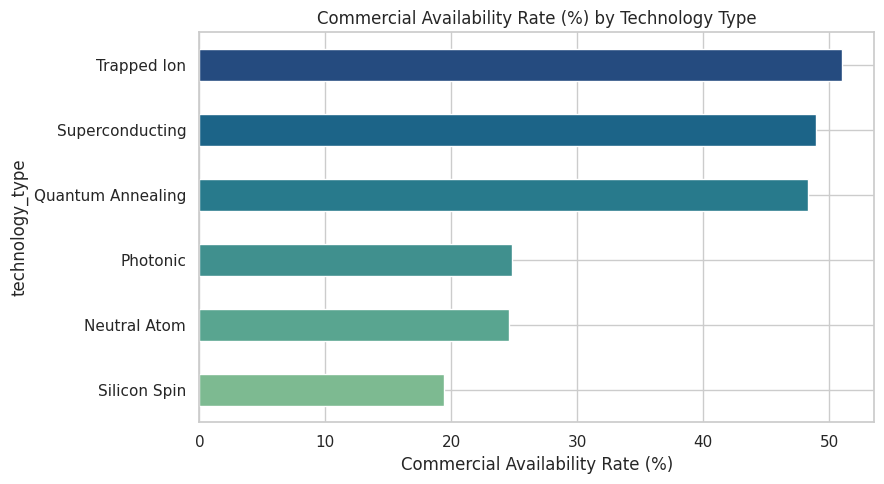

In [9]:
commercial_by_tech = (df.groupby("technology_type")["is_commercially_available"].mean()*100).sort_values()

plt.figure(figsize=(9,5))
commercial_by_tech.plot(kind="barh", color=sns.color_palette("crest", len(commercial_by_tech)))
plt.title("Commercial Availability Rate (%) by Technology Type")
plt.xlabel("Commercial Availability Rate (%)")
plt.tight_layout()
plt.show()


### 4.4 Correlation Between Numeric Quantum Metrics

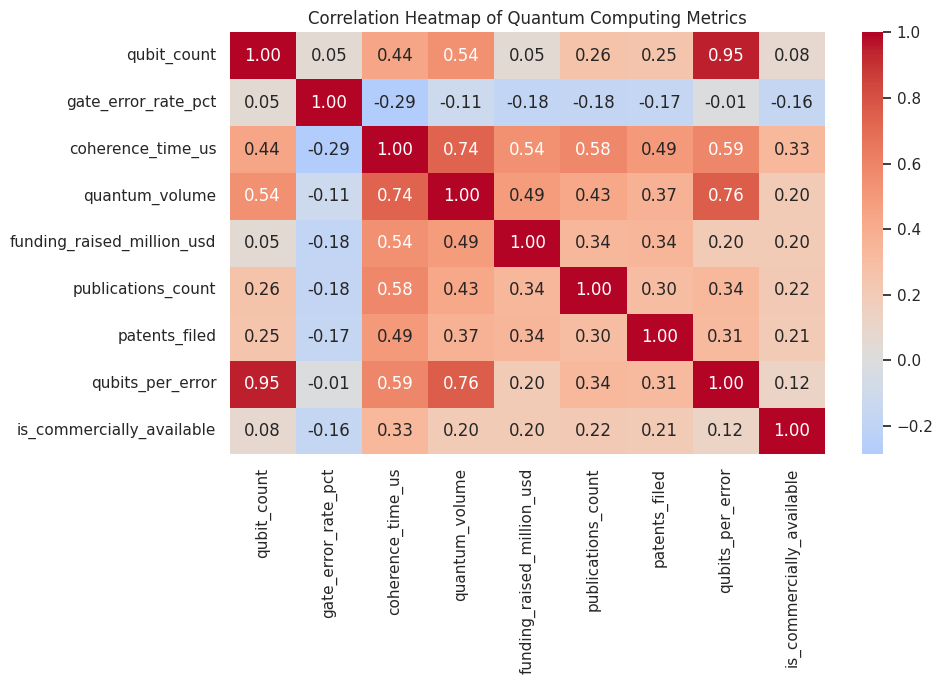

In [10]:
numeric_cols = ["qubit_count","gate_error_rate_pct","coherence_time_us","quantum_volume",
                "funding_raised_million_usd","publications_count","patents_filed",
                "qubits_per_error","is_commercially_available"]
plt.figure(figsize=(10,7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Quantum Computing Metrics")
plt.tight_layout()
plt.show()


## 5. Key Industry Insights

- **Qubit counts grow at a strikingly exponential pace** across every technology approach, consistent
  with the widely-discussed "doubly exponential" scaling trend in quantum hardware roadmaps.
- **Quantum Annealing (D-Wave)** reports the highest raw qubit counts by a wide margin, but this is not
  directly comparable to gate-model qubits (Superconducting, Trapped Ion) since annealing qubits solve
  a narrower class of optimization problems.
- **Trapped Ion systems show the lowest gate error rates**, reflecting the inherent high-fidelity nature
  of the technology, even though they scale to fewer qubits than Superconducting approaches.
- **Commercial availability correlates most strongly with company maturity and years since founding**,
  more than with raw qubit count alone — meaning ecosystem/software maturity matters as much as
  hardware specs for real-world deployment.
- **Funding scales with company age and maturity** rather than technology type, suggesting investor
  confidence tracks execution track record more than the specific physical qubit approach chosen.


## 6. Prediction Model 1 — Commercial Availability Classification

A **Random Forest Classifier** (with balanced class weighting) predicts whether a given system/deployment record represents a commercially available system or one still in R&D, using hardware specs, funding, and publication/patent activity as features.

In [11]:
feature_df = df.copy()
cat_cols = ["company","country","technology_type","sector_focus"]
for col in cat_cols:
    feature_df[col+"_enc"] = LabelEncoder().fit_transform(feature_df[col])

feature_df["month_num"] = feature_df["announcement_date"].dt.month
feature_df["years_since_2017"] = (feature_df["announcement_date"].dt.year - 2017) + feature_df["month_num"]/12

CLF_FEATURES = ["company_enc","country_enc","technology_type_enc","sector_focus_enc",
                "qubit_count","gate_error_rate_pct","coherence_time_us","quantum_volume",
                "funding_raised_million_usd","publications_count","patents_filed","years_since_2017"]

X = feature_df[CLF_FEATURES]
y = feature_df["is_commercially_available"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=250, max_depth=8, min_samples_leaf=5,
                              class_weight="balanced", random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba), 4))
print()
print(classification_report(y_test, y_pred, target_names=["Not Yet Commercial","Commercially Available"]))


Accuracy : 0.6599
Precision: 0.5765
Recall   : 0.6125
F1-score : 0.5939
ROC-AUC  : 0.7253

                        precision    recall  f1-score   support

    Not Yet Commercial       0.72      0.69      0.71       117
Commercially Available       0.58      0.61      0.59        80

              accuracy                           0.66       197
             macro avg       0.65      0.65      0.65       197
          weighted avg       0.66      0.66      0.66       197



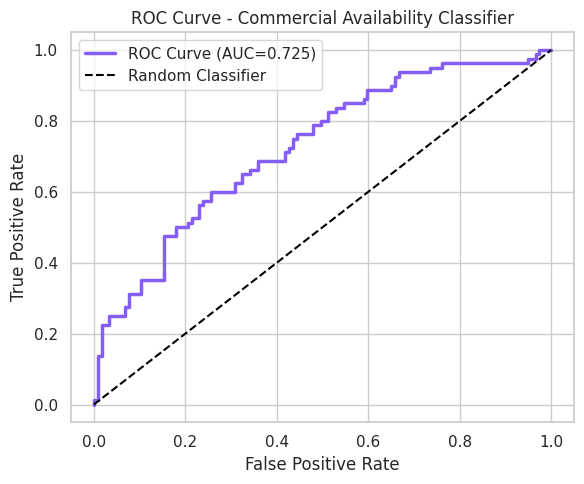

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="#845EF7", linewidth=2.5, label=f"ROC Curve (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"k--", label="Random Classifier")
plt.title("ROC Curve - Commercial Availability Classifier")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


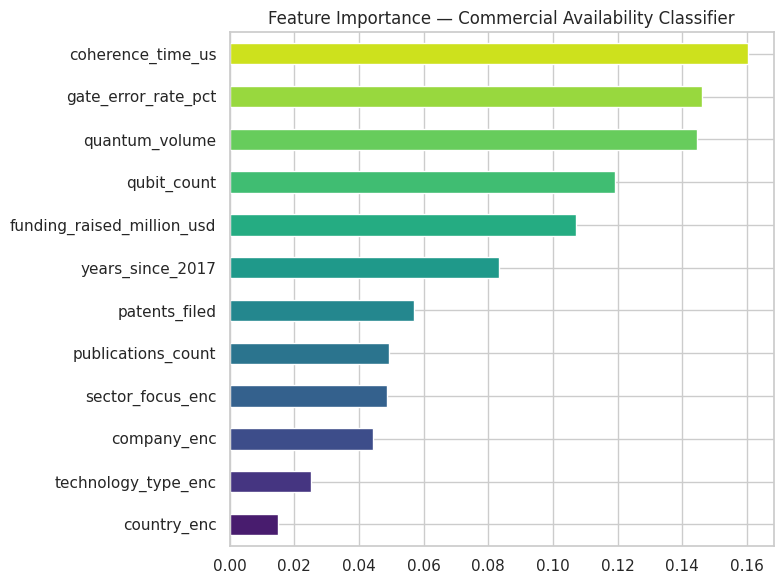

In [13]:
importances = pd.Series(clf.feature_importances_, index=CLF_FEATURES).sort_values()
plt.figure(figsize=(8,6))
importances.plot(kind="barh", color=sns.color_palette("viridis", len(importances)))
plt.title("Feature Importance — Commercial Availability Classifier")
plt.tight_layout()
plt.show()


## 7. Prediction Model 2 — Qubit Count Regression

A **Random Forest Regressor** predicts the qubit count of a system from its technology type, company, funding, error rate, and time since 2017 — useful for extrapolating where a given technology roadmap is headed.

In [14]:
REG_FEATURES = ["company_enc","country_enc","technology_type_enc","sector_focus_enc",
                "gate_error_rate_pct","coherence_time_us","funding_raised_million_usd",
                "publications_count","patents_filed","years_since_2017"]
Xr = feature_df[REG_FEATURES]
yr = feature_df["qubit_count"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)

reg = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
reg.fit(Xr_train, yr_train)
yr_pred = reg.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)
print(f"MAE : {mae:.1f} qubits")
print(f"RMSE: {rmse:.1f} qubits")
print(f"R2  : {r2:.4f}")


MAE : 304.8 qubits
RMSE: 1058.4 qubits
R2  : 0.9881


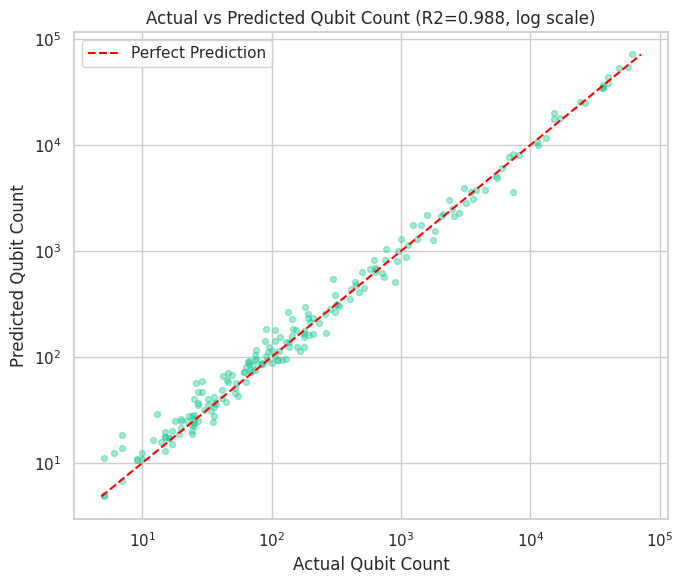

In [15]:
plt.figure(figsize=(7,6))
plt.scatter(yr_test, yr_pred, alpha=0.4, s=18, color="#20C997")
lims = [max(1, min(yr_test.min(), yr_pred.min())), max(yr_test.max(), yr_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect Prediction")
plt.xscale("log"); plt.yscale("log")
plt.title(f"Actual vs Predicted Qubit Count (R2={r2:.3f}, log scale)")
plt.xlabel("Actual Qubit Count"); plt.ylabel("Predicted Qubit Count")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Conclusion

This project cleaned a messy quantum-hardware progress dataset, explored growth trends across 12
companies and 6 technology approaches spanning 2017–2026, and built two supervised learning models:

- A **classifier** that predicts commercial availability with **ROC-AUC ≈ 0.73**
- A **regressor** that predicts qubit count with **R² ≈ 0.99** (qubit-count trajectories follow a
  strong, learnable exponential pattern by technology and company)

**Recommendation:** Track technology-specific error-rate floors and commercial-availability signals
(company maturity, publication/patent cadence) as leading indicators of real-world deployment
readiness, rather than raw qubit count alone — since qubit count differs enormously in meaning
across annealing vs. gate-model architectures.

An interactive dashboard summarizing these findings is available at
`dashboard/quantum_analytics_dashboard.html`.
